This notebook works through data processed by Jakob Doerr into .mat and .npy format, and converts it to netcdf using xarray.

In [1]:
import numpy as np
import os
from scipy.io import savemat,loadmat,whosmat
import numpy.ma as ma
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#--------Common definitions
nm = 12
ls = ['-','-.',':','--']
ls = np.tile(ls,20)
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
nummonths = ['01','02','03','04','05','06','07','08','09','10','11','12']
outdir = '/Users/lettieroach/Documents/SIMIP_scripts/processed_netcdf/'
myhemi = ['sh','nh']

Three sets of satellite observations

In [3]:
mydir = '../SIMIP_scripts/data/'
myfiles = sorted([f for f in (os.listdir(mydir)) if 'SIA' in f])
obsnames = ['nsidc_bt','nsidc_nt','osisaf']
obspnames = ['Bootstrap','NASA Team','OSISAF']

alldata = []
for o in obsnames:
    hemidata = []
    for h in myhemi:
        obs_data = np.load(mydir+'SIA_'+o+'_monthly_'+h+'.npy',allow_pickle=True)
        mydata = np.zeros([40,nm])
        for m, month in enumerate(nummonths):
            mydata[:,m] = obs_data[month][0,:]
        hemidata.append(mydata)
    alldata.append(hemidata)
alldata = np.asarray(alldata)
print(alldata.shape)

ds = xr.Dataset(data_vars = { 'sia_nh' : xr.DataArray(alldata[:,1,:,:], dims=['name','year','month']),
                              'sia_sh' : xr.DataArray(alldata[:,0,:,:], dims=['name','year','month'])},                              
                       coords    = { 'name' : obspnames,
                                     'year' : obs_data['years'], 'month' : np.arange(1,nm+1,1)},
            attrs= {
             'description'  : 'Sea ice area from satellite observations',
             'generation'   : 'Observations',
             'processed by' : 'Jakob Doerr, MPI, 2019',
             'netcdf file created by' : 'Lettie Roach, UW, 2019'}
                     )
ds.sia_nh.attrs['long_name'] = 'sea_ice_area_nh'
ds.sia_sh.attrs['long_name'] = 'sea_ice_area_sh'

ds.sia_nh.attrs['units'] = 'million km^2'
ds.sia_sh.attrs['units'] = 'million km^2'

print(ds)
#ds.to_netcdf(outdir+'processed_OBS_sia_1979-2018.nc')

(3, 2, 40, 12)
<xarray.Dataset>
Dimensions:  (month: 12, name: 3, year: 40)
Coordinates:
  * name     (name) <U9 'Bootstrap' 'NASA Team' 'OSISAF'
  * year     (year) int64 1979 1980 1981 1982 1983 ... 2014 2015 2016 2017 2018
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    sia_nh   (name, year, month) float64 14.71 15.45 15.48 ... 5.102 8.936 10.87
    sia_sh   (name, year, month) float64 3.835 2.384 3.048 ... 15.17 11.88 6.256
Attributes:
    description:             Sea ice area from satellite observations
    generation:              Observations
    processed by:            Jakob Doerr, MPI, 2019
    netcdf file created by:  Lettie Roach, UW, 2019


Historical plus SRESA1B for CMIP3

In [4]:
cmip3file = '../SIMIP_scripts/data/CMIP3/alldata_C3.mat'
struct = loadmat(cmip3file)
my_dict = struct['matched']

model_names  = sorted(np.concatenate(my_dict[0][0][0][0],axis=0)) # includes duplicates
model_names = [i.replace('_','-') for i in model_names]
realizations = my_dict[0][0][1][0]
months       = my_dict[0][0][2][0]
years        = my_dict[0][0][3][0]

ny = int(len(years)/nm)
varnames = ['sia_nh','sia_sh','sie_nh','sie_sh','gmst']
myvars = [my_dict[0][0][i]/1e6 for i in [4,5,6,7]]
myvars.append(my_dict[0][0][8])
print(my_dict[0][0][8][0,:12])
myvars = np.asarray(myvars).reshape(len(varnames),len(model_names),ny,nm)

unique_model_names = []
unique_vars = []
unique_id = []
for n, model in enumerate(model_names):
    if model not in unique_model_names:
        unique_model_names.append(model)
        unique_vars.append(myvars[:,n,:,:])
        unique_id.append(model+'_r'+str(realizations[n]))
unique_vars = np.asarray(unique_vars)
print(unique_vars.shape)
ds = xr.Dataset(data_vars = {varnames[v] : xr.DataArray(unique_vars[:,v,:,:], 
                                dims=['name','year','month']) for v in range(len(varnames))},
                       coords    = { 'name' : unique_id,
                                     'year' : sorted(list(set(years))),'month' : np.arange(1,nm+1,1)},
            attrs= {
             'description'  : 'Sea ice area, extent and GMST from CMIP3',
             'generation'   : 'CMIP3',
             'experiment'   : 'historical + SRESA1B',
             'processed by' : 'Jakob Doerr, MPI, 2019',
             'netcdf file created by' : 'Lettie Roach, UW, 2019'}
               )      

ds.sia_nh.attrs['long_name'] = 'sea_ice_area_nh'
ds.sia_sh.attrs['long_name'] = 'sea_ice_area_sh'
ds.sie_nh.attrs['long_name'] = 'sea_ice_extent_nh'
ds.sie_sh.attrs['long_name'] = 'sea_ice_extent_sh'
ds.gmst.attrs['long_name'] = 'global_mean_surface_temperature'

for var in varnames[:-1]:
    ds[var].attrs['units'] = 'million km^2'
ds['gmst'].attrs['units'] = 'K'

todrop = [f for f in ds.name.values if 'iap-fgoals1-0-g' in f]

ds = ds.drop(name=todrop)
print(ds)

#ds.to_netcdf(outdir+'processed_CMIP3_sia_historical+SRES1AB_r1.nc')

[283.13393387 283.42531469 284.52010779 285.86717165 286.82291118
 287.57887009 287.76828229 287.45904648 286.68407175 285.54156844
 284.37469364 283.47515955]
(20, 5, 200, 12)
<xarray.Dataset>
Dimensions:  (month: 12, name: 19, year: 200)
Coordinates:
  * name     (name) <U20 'bccr-bcm2-0_r1' ... 'ukmo-hadgem1_r1'
  * year     (year) uint16 1900 1901 1902 1903 1904 ... 2095 2096 2097 2098 2099
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    sia_nh   (name, year, month) float64 14.09 15.65 15.96 ... 0.352 1.733 5.439
    sia_sh   (name, year, month) float64 2.255 1.402 1.483 ... 14.96 12.41 7.555
    sie_nh   (name, year, month) float64 15.45 17.22 17.44 ... 2.935 7.526
    sie_sh   (name, year, month) float64 3.295 1.801 1.956 ... 18.19 17.42 12.7
    gmst     (name, year, month) float64 283.1 283.4 284.5 ... 289.7 288.7 287.8
Attributes:
    description:             Sea ice area, extent and GMST from CMIP3
    generation:              CMIP3
    experiment:  

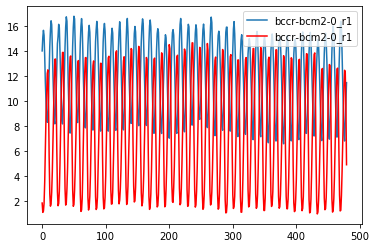

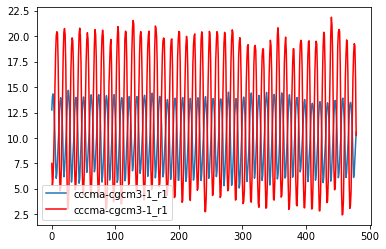

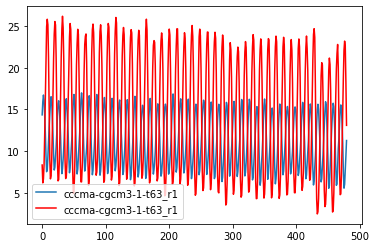

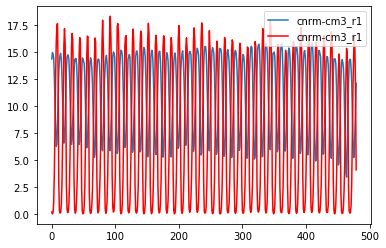

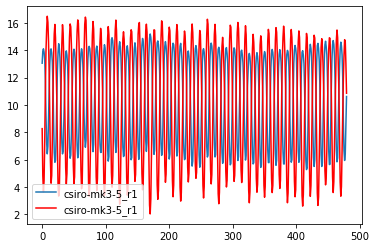

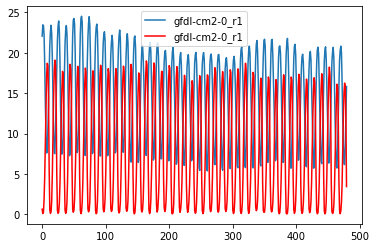

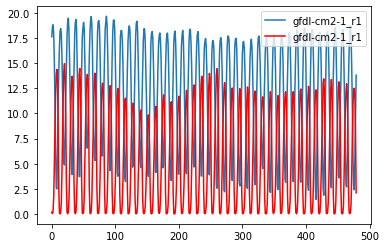

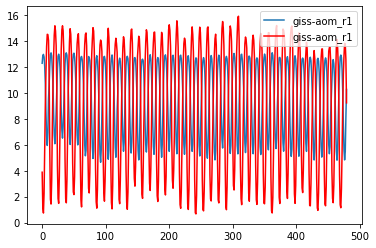

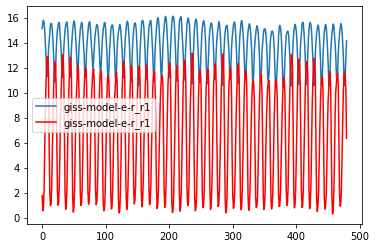

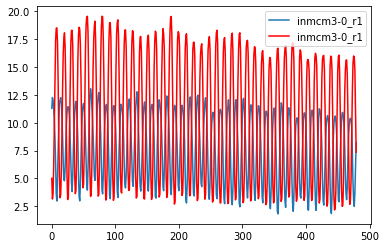

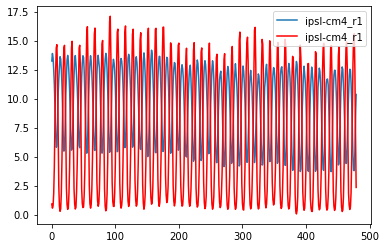

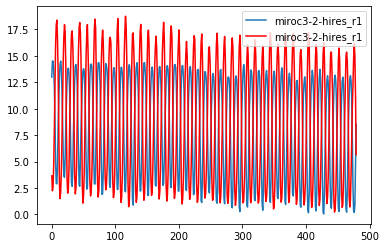

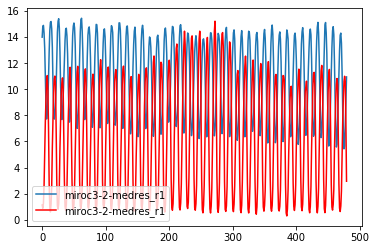

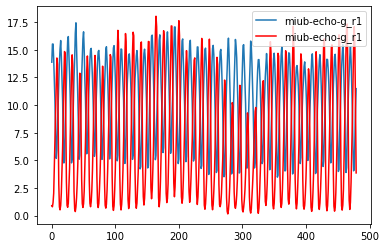

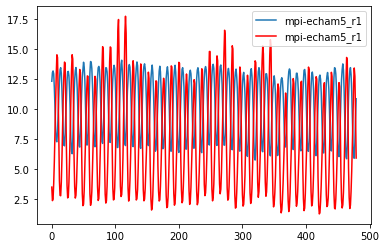

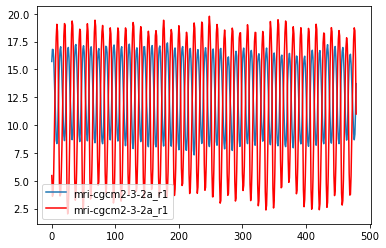

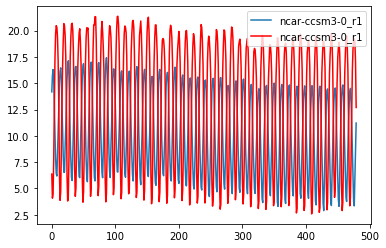

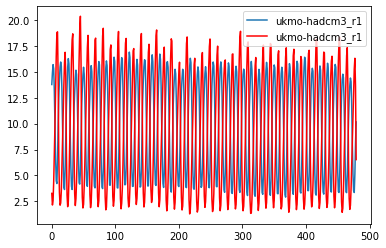

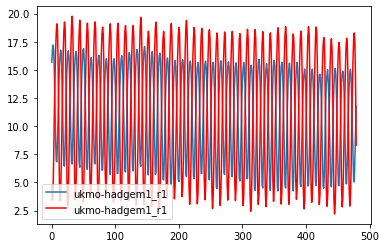

In [5]:
# sanity check
for m in ds.name.values:
    fig, ax = plt.subplots(1)
    toplot = ds.sia_nh.sel(name=m).sel(year=slice('1979','2018'))
    ax.plot(np.arange(40*12),toplot.values.flatten(),label=m)
    toplot = ds.sia_sh.sel(name=m).sel(year=slice('1979','2018'))
    ax.plot(np.arange(40*12),toplot.values.flatten(),label=m,c='red')
   
    plt.legend()
    plt.show()
    plt.close()

CMIP5 - historical and rcp45 separately. The rcp45 file also includes the historical data. Save only the first ensemble member.

(188, 156)
removing
historical CMCC-CESM_r1i1p1       


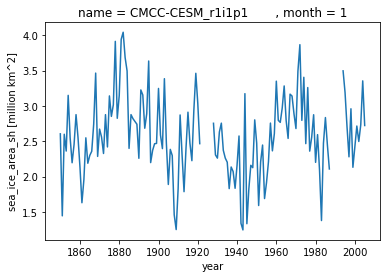

historical CanCM4_r1i1p1          


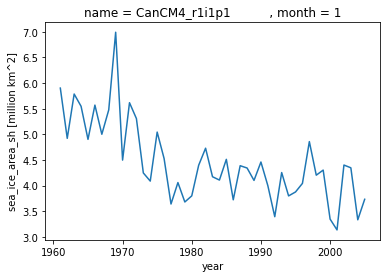

historical FGOALS-s2_r2i1p1       


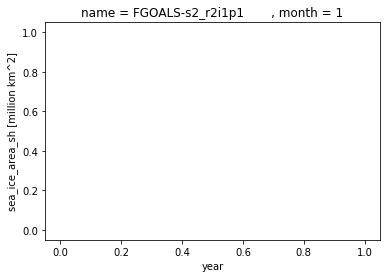

historical fio-esm_r1i1p1         


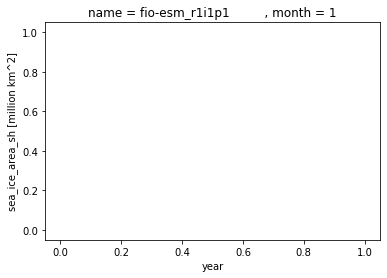

<xarray.Dataset>
Dimensions:  (month: 12, name: 47, year: 156)
Coordinates:
  * name     (name) object 'ACCESS1-0_r1i1p1       ' ... 'inmcm4_r1i1p1          '
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2001 2002 2003 2004 2005
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    sia_sh   (name, year, month) float64 2.891 1.801 2.279 ... 7.225 5.726 2.781
    siv_sh   (name, year, month) float64 4.626 2.665 2.242 ... 8.122 6.686 2.959
    sia_nh   (name, year, month) float64 14.12 14.88 15.2 ... 6.207 8.979 11.2
    siv_nh   (name, year, month) float64 23.88 27.47 30.29 ... 6.355 9.747 14.0
    gmst     (name, year) float64 286.9 286.8 286.8 287.0 ... 286.9 287.1 287.0
Attributes:
    description:             Sea ice area, volume and GMST from CMIP5
    experiment:              historical
    generation:              CMIP5
    processed by:            Jakob Doerr, MPI, 2019
    netcdf file created by:  Lettie Roach, UW, 2019
(143, 250)
removing
rcp45 CES

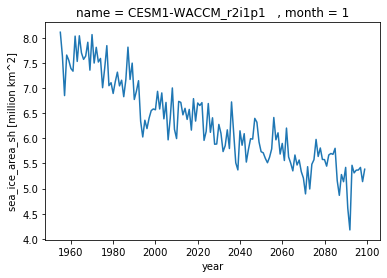

rcp45 CanCM4_r1i1p1        


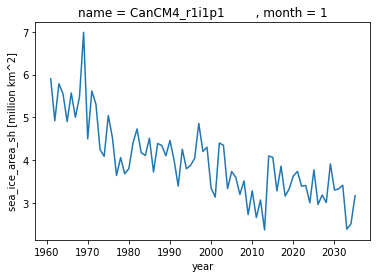

rcp45 GFDL-CM2p1_r1i1p1    


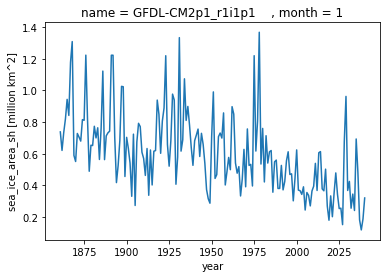

rcp45 HadCM3_r1i1p1        


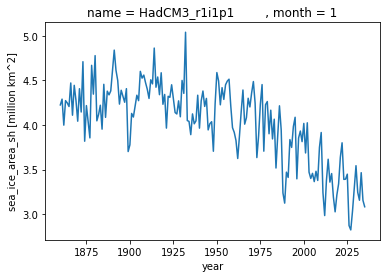

rcp45 MIROC4h_r1i1p1       


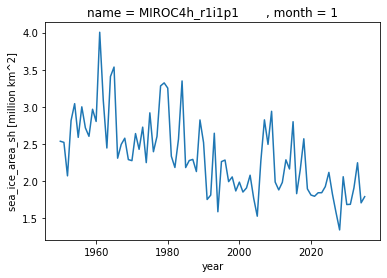

rcp45 fio-esm_r1i1p1       


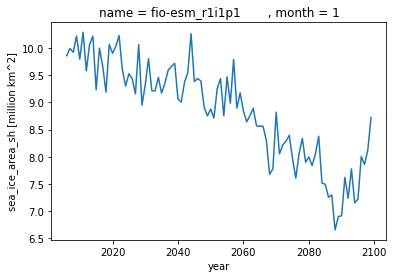

<xarray.Dataset>
Dimensions:  (month: 12, name: 38, year: 250)
Coordinates:
  * name     (name) object 'ACCESS1-0_r1i1p1     ' ... 'inmcm4_r1i1p1        '
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2095 2096 2097 2098 2099
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    sia_sh   (name, year, month) float64 2.891 1.801 2.279 ... 5.296 3.828 1.84
    siv_sh   (name, year, month) float64 4.626 2.665 2.242 ... 4.548 3.678 1.625
    sia_nh   (name, year, month) float64 14.12 14.88 15.2 ... 3.586 5.984 9.134
    siv_nh   (name, year, month) float64 23.88 27.47 30.29 ... 3.023 4.651 8.039
    gmst     (name, year) float64 286.9 286.8 286.8 287.0 ... 288.1 288.1 288.2
Attributes:
    description:             Sea ice area, volume and GMST from CMIP5
    experiment:              rcp45
    generation:              CMIP5
    processed by:            Jakob Doerr, MPI, 2019
    netcdf file created by:  Lettie Roach, UW, 2019


In [6]:
scenarios = ['historical','rcp45']
cmippath = '../SIMIP_scripts/data/CMIP5/'
varnames = ['sia_nh','siv_nh','sia_sh','siv_sh']

scends = []
myrecord = []
varnames = ['sia_sh','siv_sh','sia_nh','siv_nh']
for scenario in scenarios:
    
    vardata = []
    for hemi in myhemi:
        
        data = loadmat(cmippath+'CMIP5_'+scenario+'_'+hemi+'.mat')
        all_model_names = data['Simulation_names']
        years = data['Years'][0]
        
        vardata.append(data['sia_'+hemi])
        vardata.append(data['siv_'+hemi])
    gmst = data['gmst']
    print(gmst.shape)
    
    vardata = np.asarray(vardata)
    model_names = [f.split('_')[0] for f in all_model_names]
    realizations = [f.split('_')[1] for f in all_model_names]
    
    unique_model_names = []
    unique_vars = []
    unique_gmst = []
    unique_id = []
    for n, model in enumerate(model_names):
        if model not in unique_model_names:
            unique_model_names.append(model)
            unique_vars.append(vardata[:,n,:,:])
            unique_gmst.append(gmst[n,:])
            unique_id.append(model+'_'+str(realizations[n]))
    unique_vars = np.asarray(unique_vars)
    unique_gmst = np.asarray(unique_gmst)

    ds = xr.Dataset(data_vars = {varnames[v] : xr.DataArray(unique_vars[:,v,:,:], 
                                dims=['name','year','month']) for v in range(len(varnames))},
                       coords    = { 'name' : unique_id, 
                                     'year' : years,   'month' : np.arange(1,nm+1,1)},
            attrs= {
             'description'  : 'Sea ice area, volume and GMST from CMIP5',
             'experiment'   : scenario,
             'generation'   : 'CMIP5',
             'processed by' : 'Jakob Doerr, MPI, 2019',
             'netcdf file created by' : 'Lettie Roach, UW, 2019'}
               )      

    ds['gmst'] =  xr.DataArray(unique_gmst, dims=['name','year'])
    ds.sia_nh.attrs['long_name'] = 'sea_ice_area_nh'
    ds.sia_sh.attrs['long_name'] = 'sea_ice_area_sh'
    ds.siv_nh.attrs['long_name'] = 'sea_ice_extent_nh'
    ds.siv_sh.attrs['long_name'] = 'sea_ice_extent_sh'
    ds.gmst.attrs['long_name'] = 'global_mean_surface_temperature'

    for var in varnames[:-1]:
        ds[var].attrs['units'] = 'million km^2'
    ds['gmst'].attrs['units'] = 'K'
    
    # get rid of models that have missing years
    print('removing')
    for m in ds.name.values:
        if np.count_nonzero(np.isnan(ds.sia_sh.sel(name=m).sel(year=slice('1950','2100')).sel(month=1).values)) > 1:
            print(scenario,m)
            ds.sia_sh.sel(name=m).sel(month=1).plot(); plt.show(); plt.close()
            ds = ds.drop(name=m)
        #if 'CSIRO-Mk3-6-0' in m:
        #    ds = ds.drop(name=m)
            

    print(ds)
    #ds.to_netcdf(outdir+'processed_CMIP5_sia_'+scenario+'_r1.nc')

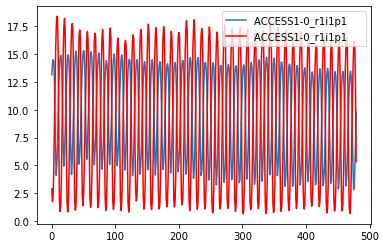

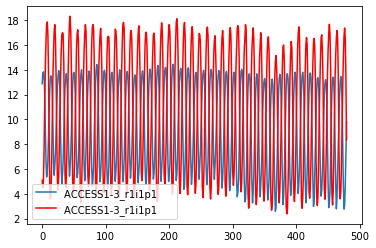

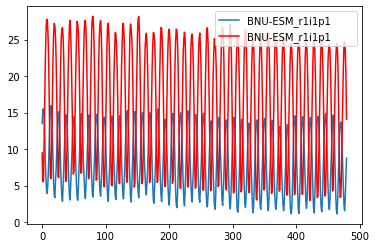

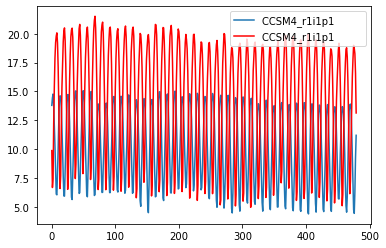

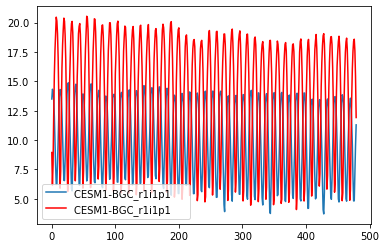

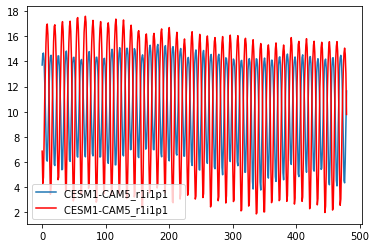

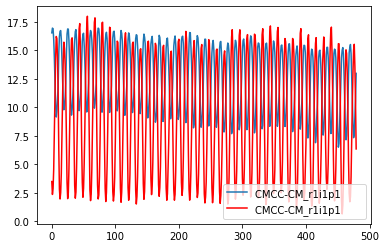

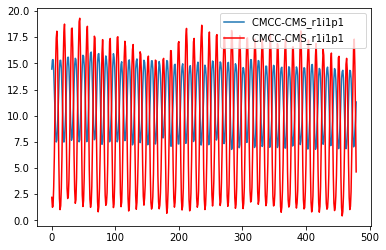

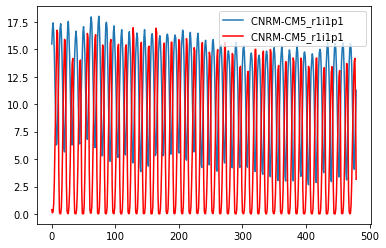

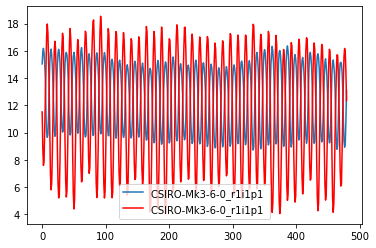

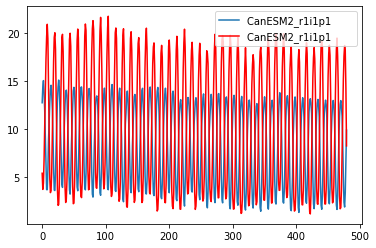

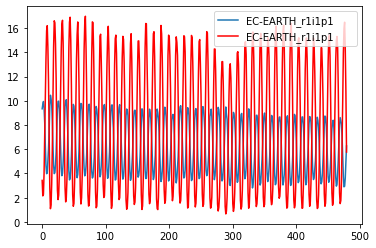

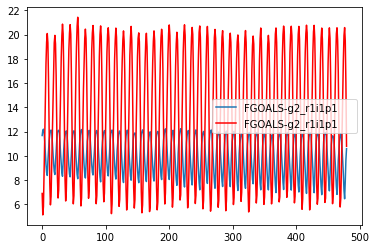

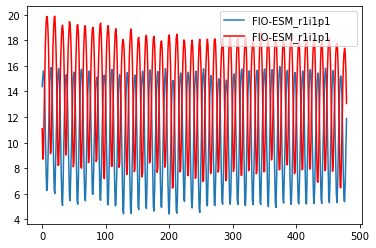

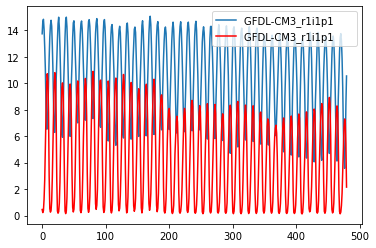

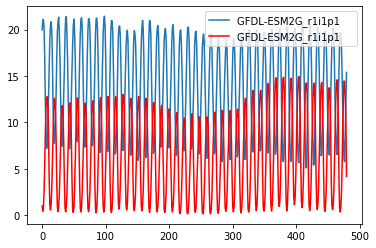

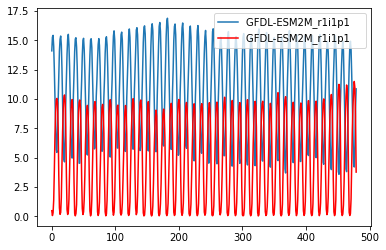

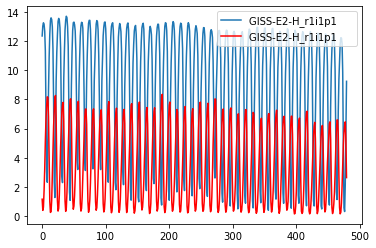

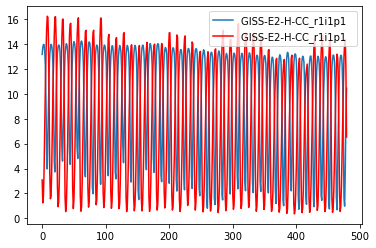

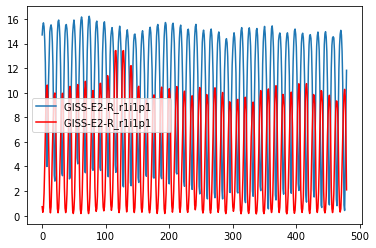

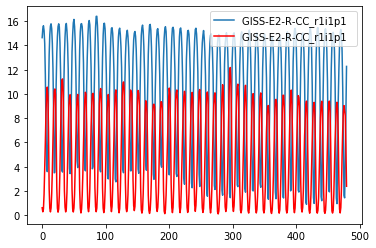

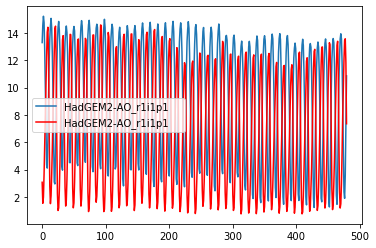

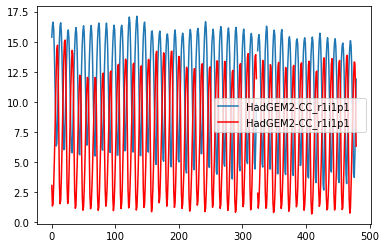

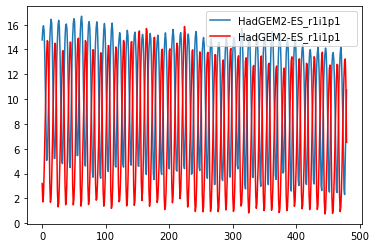

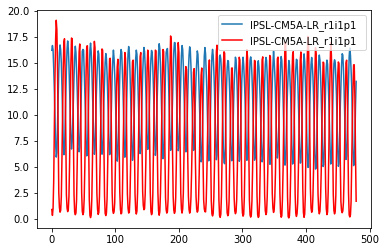

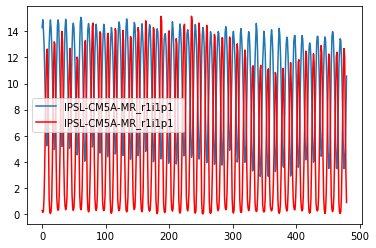

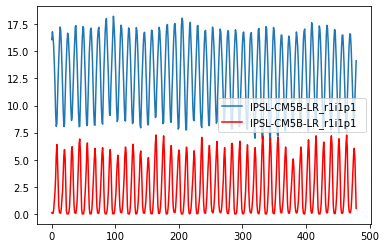

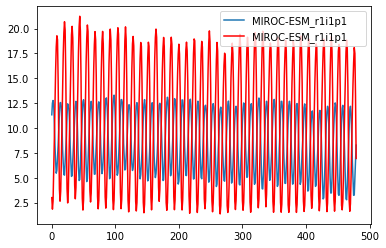

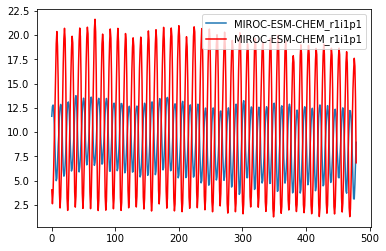

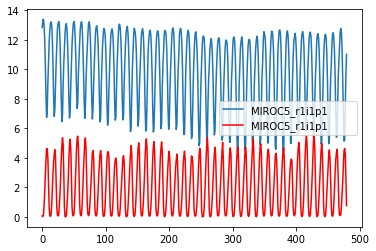

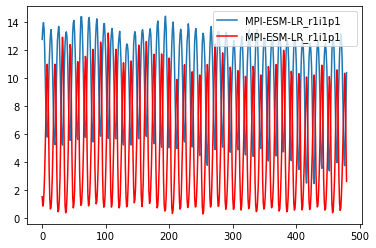

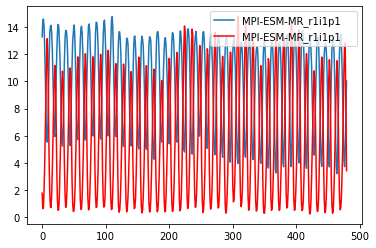

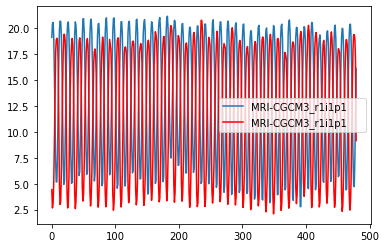

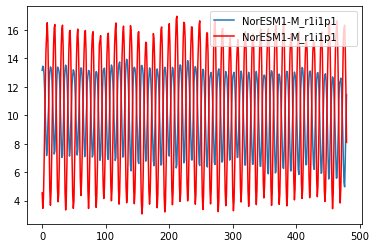

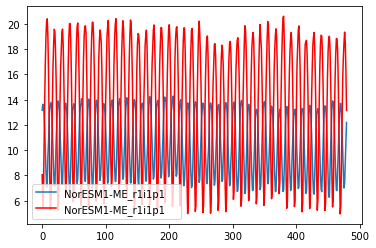

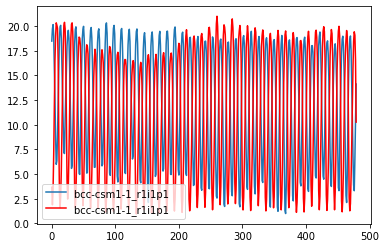

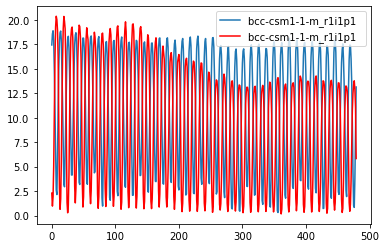

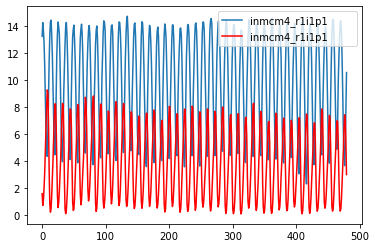

In [7]:
# sanity check
for m in ds.name.values:
    fig, ax = plt.subplots(1)
    toplot = ds.sia_nh.sel(name=m).sel(year=slice('1979','2018'))
    ax.plot(np.arange(40*12),toplot.values.flatten(),label=m)
    toplot = ds.sia_sh.sel(name=m).sel(year=slice('1979','2018'))
    ax.plot(np.arange(40*12),toplot.values.flatten(),label=m,c='red')
   
    plt.legend()
    plt.show()
    plt.close()

CMIP6 - all scenarios individually. Save only the first ensemble member

In [8]:
scenarios = ['historical','ssp245','ssp126','ssp585']
cmippath = '../SIMIP_scripts/data/CMIP6/'
varnames = ['sia_sh','siv_sh','sia_nh','siv_nh']

for scenario in scenarios:
    print(scenario)
    vardata = []
    
    
    sh_data = loadmat(cmippath+'CMIP6_'+scenario+'_sh.mat')
    sh_model_names = sh_data['Simulation_names']
    sh_model_names = [f.strip() for f in sh_model_names]   
    
    nh_data = loadmat(cmippath+'CMIP6_'+scenario+'_nh.mat')
    nh_model_names = nh_data['Simulation_names']
    nh_model_names = [f.strip() for f in nh_model_names]
    
    years = sh_data['Years'][0]
    nans = np.zeros([len(years),nm])
    nans[:,:] = np.nan
    
    unique_sia_sh = []
    unique_siv_sh = []
    unique_gmst_sh = []
    unique_id_sh = []   
    unique_model_names = []
    for n, model in enumerate(sh_model_names):
         if model.split('_')[0] not in unique_model_names and 'CAMS-CSM1-0_r1i1p1f2' not in model and 'FGOALS-g3' not in model:
                unique_model_names.append(model.split('_')[0])
                unique_sia_sh.append(sh_data['sia_sh'][n,:,:])
                unique_siv_sh.append(sh_data['siv_sh'][n,:,:])
                unique_gmst_sh.append(sh_data['gmst'][n,:])
                unique_id_sh.append(model) 
                
               
                
    ds_sh = xr.Dataset(data_vars = {'sia_sh' : xr.DataArray(np.asarray(unique_sia_sh),dims=['name','year','month']),
                                    'siv_sh' : xr.DataArray(np.asarray(unique_siv_sh),dims=['name','year','month'])},
                       coords    = { 'name' : unique_id_sh,
                                     'year' : years,   'month' : np.arange(1,nm+1,1)})
    ds_sh['gmst'] =  xr.DataArray(unique_gmst_sh, dims=['name','year']) 
    
                
    unique_id_nh = []
    unique_sia_nh = []
    unique_siv_nh = []
    unique_model_names = []
    
    for n, model in enumerate(nh_model_names):
            if model.split('_')[0] not in unique_model_names and 'CAMS-CSM1-0_r1i1p1f2' not in model and 'FGOALS-g3' not in model:
                unique_model_names.append(model.split('_')[0])
                unique_id_nh.append(model)
                if model in sh_model_names:
                    unique_sia_nh.append(nh_data['sia_nh'][n,:,:])
                    unique_siv_nh.append(nh_data['siv_nh'][n,:,:])
                else:
                    unique_sia_nh.append(nans)
                    unique_siv_nh.append(nans)
                    
            if 'CNRM-CM6-1-HR' in model:
                    print(model,nh_data['gmst'][n,:])
                    print(model,nh_data['sia_nh'][n,:])
               

    ds_nh = xr.Dataset(data_vars = {'sia_nh' : xr.DataArray(np.asarray(unique_sia_nh),dims=['name','year','month']),
                                    'siv_nh' : xr.DataArray(np.asarray(unique_siv_nh),dims=['name','year','month'])},
                       coords    = { 'name' : unique_id_nh,
                                     'year' : years,   'month' : np.arange(1,nm+1,1)})
       
    ds = xr.merge([ds_nh,ds_sh])
    ds.attrs= {
             'description'  : 'Sea ice area, volume and GMST from CMIP6',
             'generation'   : 'CMIP6',
             'experiment'   : scenario,
             'processed by' : 'Jakob Doerr, MPI, 2020',
             'netcdf file created by' : 'Lettie Roach, UW, 2020'}
                     

    
    ds.sia_nh.attrs['long_name'] = 'sea_ice_area_nh'
    ds.sia_sh.attrs['long_name'] = 'sea_ice_area_sh'
    ds.siv_nh.attrs['long_name'] = 'sea_ice_extent_nh'
    ds.siv_sh.attrs['long_name'] = 'sea_ice_extent_sh'
    ds.gmst.attrs['long_name'] = 'global_mean_surface_temperature'

    for var in varnames[:-1]:
        ds[var].attrs['units'] = 'million km^2'
    ds['gmst'].attrs['units'] = 'K'
    
    # get rid of models that have missing years
    print('removing')
    if scenario == 'historical':
        tocheck = ds.sia_sh.sel(year=slice('1950','2014'))
    else:
        tocheck = ds.sia_sh
        
    for m in ds.name.values:
        if np.count_nonzero(np.isnan(tocheck.sel(name=m).sel(month=1).values)) > 1:
            print(scenario,m)
            print(tocheck.sel(name=m).sel(month=1).values)
            ds = ds.drop(name=m)
        
             
    print(ds.name.values)
    
    
    ds.to_netcdf(outdir+'processed_CMIP6_sia_'+scenario+'_r1_updated.nc')

historical
CNRM-CM6-1-HR_r1i1p1f2 [285.56484985 285.49453735 285.53625488 285.57400513 285.56051636
 285.64120483 285.5262146  285.50860596 285.43487549 285.52044678
 285.53768921 285.33718872 285.4395752  285.43392944 285.40643311
 285.45892334 285.47836304 285.37210083 285.41827393 285.45596313
 285.47418213 285.47097778 285.40991211 285.44836426 285.44503784
 285.56317139 285.46636963 285.47402954 285.46194458 285.49319458
 285.63134766 285.42736816 285.60821533 285.60079956 285.37905884
 285.33221436 285.56408691 285.63513184 285.77554321 285.63284302
 285.572052   285.54663086 285.61270142 285.64532471 285.58267212
 285.66357422 285.51269531 285.51611328 285.6078186  285.67855835
 285.63452148 285.63931274 285.66928101 285.56069946 285.50186157
 285.55691528 285.66363525 285.51647949 285.45343018 285.47595215
 285.53771973 285.55645752 285.61639404 285.51583862 285.66363525
 285.693573   285.71377563 285.7265625  285.68972778 285.70574951
 285.72561646 285.63595581 285.62973022 28

CMIP6 - historical and ssp245 - all ensemble members

In [9]:
scenarios = ['historical','ssp245','ssp126','ssp585']
cmippath = '../SIMIP_scripts/data/CMIP6/'
varnames = ['sia_sh','siv_sh','sia_nh','siv_nh']

for scenario in scenarios:
    print(scenario)
    vardata = []
    
    
    sh_data = loadmat(cmippath+'CMIP6_'+scenario+'_sh.mat')
    sh_model_names = sh_data['Simulation_names']
    sh_model_names = [f.strip() for f in sh_model_names]       
    
    nh_data = loadmat(cmippath+'CMIP6_'+scenario+'_nh.mat')
    nh_model_names = nh_data['Simulation_names']
    nh_model_names = [f.strip() for f in nh_model_names]
    
    all_model_names = sh_model_names#[f for f in nh_model_names if f in sh_model_names]
    years = sh_data['Years'][0]
    
    unique_sia_sh = []
    unique_siv_sh = []
    unique_gmst_sh = []
    unique_id_sh = []    
    for n, model in enumerate(sh_model_names):
        if model in all_model_names and 'FGOALS-g3' not in model:
                unique_sia_sh.append(sh_data['sia_sh'][n,:,:])
                unique_siv_sh.append(sh_data['siv_sh'][n,:,:])
                unique_gmst_sh.append(sh_data['gmst'][n,:])
                if 'CNRM-CM6-1-HR' in model:
                    print(model,sh_data['gmst'][n,:])
                unique_id_sh.append(model) 
                
    ds_sh = xr.Dataset(data_vars = {'sia_sh' : xr.DataArray(np.asarray(unique_sia_sh),dims=['name','year','month']),
                                    'siv_sh' : xr.DataArray(np.asarray(unique_siv_sh),dims=['name','year','month'])},
                       coords    = { 'name' : unique_id_sh,
                                     'year' : years,   'month' : np.arange(1,nm+1,1)})
    ds_sh['gmst'] =  xr.DataArray(unique_gmst_sh, dims=['name','year']) 
    
                
    unique_id_nh = []
    unique_sia_nh = []
    unique_siv_nh = []
    for n, model in enumerate(nh_model_names):
        if model in all_model_names:
                unique_id_nh.append(model)
                unique_sia_nh.append(nh_data['sia_nh'][n,:,:])
                unique_siv_nh.append(nh_data['siv_nh'][n,:,:])
    
    ds_nh = xr.Dataset(data_vars = {'sia_nh' : xr.DataArray(np.asarray(unique_sia_nh),dims=['name','year','month']),
                                    'siv_nh' : xr.DataArray(np.asarray(unique_siv_nh),dims=['name','year','month'])},
                       coords    = { 'name' : unique_id_nh,
                                     'year' : years,   'month' : np.arange(1,nm+1,1)})
   
              
            
    ds = xr.merge([ds_nh,ds_sh])
    ds.attrs= {
             'description'  : 'Sea ice area, volume and GMST from CMIP6',
             'generation'   : 'CMIP6',
             'experiment'   : scenario,
             'processed by' : 'Jakob Doerr, MPI, 2020',
             'netcdf file created by' : 'Lettie Roach, UW, 2020'}  

    ds.sia_nh.attrs['long_name'] = 'sea_ice_area_nh'
    ds.sia_sh.attrs['long_name'] = 'sea_ice_area_sh'
    ds.siv_nh.attrs['long_name'] = 'sea_ice_extent_nh'
    ds.siv_sh.attrs['long_name'] = 'sea_ice_extent_sh'
    ds.gmst.attrs['long_name'] = 'global_mean_surface_temperature'

    for var in varnames[:-1]:
        ds[var].attrs['units'] = 'million km^2'
    ds['gmst'].attrs['units'] = 'K'
    
    # get rid of models that have missing years
    print('removing')
    if scenario == 'historical':
        tocheck = ds.sia_sh.sel(year=slice('1950','2014'))
    else:
        tocheck = ds.sia_sh
    for m in ds.name.values:
        if np.count_nonzero(np.isnan(tocheck.sel(name=m).sel(month=1).values)) > 1:
            print(scenario,m)
            ds = ds.drop(name=m)
            
    print(ds)
    ds.to_netcdf(outdir+'processed_CMIP6_sia_'+scenario+'_allr_updated.nc')

historical
CNRM-CM6-1-HR_r1i1p1f2 [285.56484985 285.49453735 285.53625488 285.57400513 285.56051636
 285.64120483 285.5262146  285.50860596 285.43487549 285.52044678
 285.53768921 285.33718872 285.4395752  285.43392944 285.40643311
 285.45892334 285.47836304 285.37210083 285.41827393 285.45596313
 285.47418213 285.47097778 285.40991211 285.44836426 285.44503784
 285.56317139 285.46636963 285.47402954 285.46194458 285.49319458
 285.63134766 285.42736816 285.60821533 285.60079956 285.37905884
 285.33221436 285.56408691 285.63513184 285.77554321 285.63284302
 285.572052   285.54663086 285.61270142 285.64532471 285.58267212
 285.66357422 285.51269531 285.51611328 285.6078186  285.67855835
 285.63452148 285.63931274 285.66928101 285.56069946 285.50186157
 285.55691528 285.66363525 285.51647949 285.45343018 285.47595215
 285.53771973 285.55645752 285.61639404 285.51583862 285.66363525
 285.693573   285.71377563 285.7265625  285.68972778 285.70574951
 285.72561646 285.63595581 285.62973022 28

ssp245 HadGEM3-GC31-LL_r2i1p1f3
ssp245 HadGEM3-GC31-LL_r3i1p1f3
ssp245 HadGEM3-GC31-LL_r4i1p1f3
ssp245 IPSL-CM6A-LR_r5i1p1f1
ssp245 IPSL-CM6A-LR_r10i1p1f1
ssp245 IPSL-CM6A-LR_r11i1p1f1
ssp245 MRI-ESM2-0_r2i1p1f1
ssp245 MRI-ESM2-0_r3i1p1f1
ssp245 MRI-ESM2-0_r4i1p1f1
ssp245 MRI-ESM2-0_r5i1p1f1
ssp245 NorESM2-LM_r1i1p1f1
ssp245 NorESM2-LM_r2i1p1f1
ssp245 NorESM2-LM_r3i1p1f1
<xarray.Dataset>
Dimensions:  (month: 12, name: 74, year: 250)
Coordinates:
  * name     (name) <U24 'ACCESS-CM2_r1i1p1f1' ... 'UKESM1-0-LL_r8i1p1f2'
  * year     (year) int64 1850 1851 1852 1853 1854 ... 2095 2096 2097 2098 2099
  * month    (month) int64 1 2 3 4 5 6 7 8 9 10 11 12
Data variables:
    sia_nh   (name, year, month) float64 14.36 15.28 15.84 ... 0.063 0.622 3.99
    siv_nh   (name, year, month) float64 26.57 30.33 33.19 ... 0.019 0.189 1.526
    sia_sh   (name, year, month) float64 2.695 0.7965 1.231 ... 10.09 7.005
    siv_sh   (name, year, month) float64 3.423 1.361 1.105 ... 12.5 12.09 8.695
    gmst 